In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import seaborn as sns

In [2]:
pip install -U statsmodels

Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv("../data/processed/final_df.csv")
df.head()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,CPI,Unemployment,Type,Size,Holiday,year,month,week,weekday,is_weekend
0,1,1,2010-02-05,24924.50,42.31,2.572,0.0,0.0,0.0,0.0,...,211.096358,8.106,A,151315,False,2010,2,5,4,False
1,29,5,2010-02-05,15552.08,24.36,2.788,0.0,0.0,0.0,0.0,...,131.527903,10.064,B,93638,False,2010,2,5,4,False
2,29,6,2010-02-05,3200.22,24.36,2.788,0.0,0.0,0.0,0.0,...,131.527903,10.064,B,93638,False,2010,2,5,4,False
3,29,7,2010-02-05,10820.05,24.36,2.788,0.0,0.0,0.0,0.0,...,131.527903,10.064,B,93638,False,2010,2,5,4,False
4,29,8,2010-02-05,20055.64,24.36,2.788,0.0,0.0,0.0,0.0,...,131.527903,10.064,B,93638,False,2010,2,5,4,False


## Holiday Effect
Is holiday weekly-sales mean different than no-holiday weekly-sales mean?

In [5]:
holiday_sales = df[df["Holiday"] == True]["Weekly_Sales"]

non_holiday_sales = df[df["Holiday"] == False]["Weekly_Sales"]

In [6]:
t_stat, p_value= stats.ttest_ind(
    holiday_sales,
    non_holiday_sales,
    equal_var= False)

In [7]:
print('T-statistics: ', t_stat)
print('P-value. ', p_value)

T-statistics:  7.000740275222607
P-value.  2.5951250265739975e-12


The test revealed a **statistically significant difference between the two groups** (p < 0.001) --> holiday periods are associated with changes in weekly sales.

## Effect Size (Cohen's d for Holiday effect)
How big is the above difference?

**Important**: in large dataset (like this one) a really small difference can still have a practical, real-world impact, let's address it.

In [10]:
def cohens_d(x, y):
    nx, ny= len(x), len(y)

    pooled_std= np.sqrt(
    ((nx-1)*np.var(x, ddof=1)+
    (ny-1)*np.var(y, ddof=1))
    / (nx+ny-2))

    return (np.mean(x) - np.mean(y))/pooled_std

In [11]:
d= cohens_d(holiday_sales, non_holiday_sales)
print("Cohen's d: ", d)

Cohen's d:  0.04995201317845191


The Welch's t-test revealed a statistically significant difference, however, **the effect size is really negligible** (Cohen's d = 0.05 - really samll), indicating that although the difference is detectable, **holiday periods have limited practical, real-world impact on weekly sales**.

**Important**: holiday periods alone do not appear to be a major driver of sales performance (**holiday effect is practically negligible**).

### If holidays alone do not meaningfully explain sales variability, what factors do?

## Store Type - ANOVA

In [15]:
df['Type'].value_counts()

Type
A    215478
B    163495
C     42597
Name: count, dtype: int64

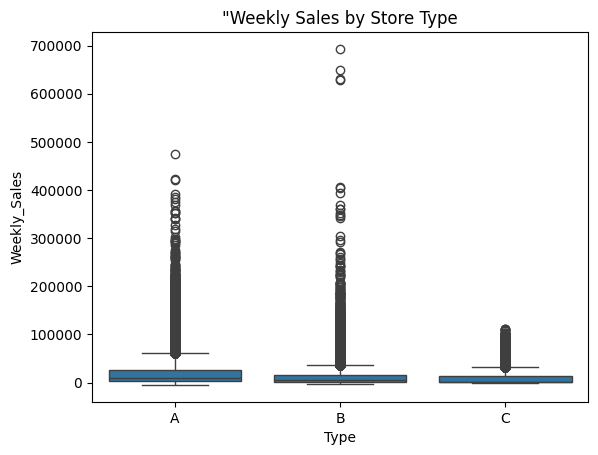

In [16]:
# Let's visualize weekly sales by store type
sns.boxplot(data=df, x='Type', y='Weekly_Sales')
plt.title('"Weekly Sales by Store Type')
plt.show();


Store Type A has the highest overall performance. Its median sales and its overall range are higher than both B and C. It also has a dense cluster of high-performing outliers stretching up to nearly 500,000.

Store Type B has slightly lower typical sales than Type A, but it features the highest individual extreme outliers, with a few weeks peaking massively between 600,000 and 700,000.

Store Type C is the lowest performer (highly consistent). It has the lowest median sales, the tightest distribution, and its maximum outliers barely scratch 100,000.

In [18]:
# ANOVA
store_groups= [
    df[df['Type'] == t] ['Weekly_Sales']
    for t in df['Type'].unique()]

f_stat, p_value= stats.f_oneway(*store_groups)

In [19]:
print('F-statistic: ', f_stat)
print('P-value: ', p_value)

F-statistic:  7764.4262174492505
P-value:  0.0


**Weekly sales differ significantly across store types.**

## Now, let's find out which stores are different - **Tukey Test**

In [22]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [23]:
tukey= pairwise_tukeyhsd(
    endog= df['Weekly_Sales'],
    groups= df['Type'],
    alpha= 0.05)
print(tukey)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
group1 group2   meandiff  p-adj    lower       upper    reject
--------------------------------------------------------------
     A      B  -7862.4921   0.0  -8033.9424  -7691.0417   True
     A      C -10580.0355   0.0 -10857.2206 -10302.8504   True
     B      C  -2717.5434   0.0  -3001.9088  -2433.1781   True
--------------------------------------------------------------


## Interpretation
The Tukey HSD post-hoc test revealed statistically significant differences across all store types (A, B, and C). 

Store type C consistently outperforms both B and A in terms of weekly sales, while store type A shows the lowest performance (meandiff -> C>B>A).

This suggests that **store classification is a key structural driver of sales differences** across the dataset.

While the boxplot suggests that Store A has relatively strong central tendency, this test indicates that Store C and B have significantly higher mean weekly sales (difference - boxplot reflects medians and distribution shape, whereas the Tukey test compares group means and accounts for sample variability -> statistically robust).

## Why does Store Type C perform better?
Multivariate analysis (regression)

## Regression
**Note**: 
- department differences -> investigated separately through ANOVA rather than included in the regression model due to the large number of categories.
- promotional analysis -> interpreted with caution and with exploratory insights only beacause Nan values were imputed with 0 (so no inference for this feature).

In [32]:
df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Type', 'Size', 'Holiday', 'year', 'month', 'week',
       'weekday', 'is_weekend'],
      dtype='object')

In [40]:
features = [
    "Size",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Holiday"
]

In [69]:
X_= df[features].copy()
y=df['Weekly_Sales']

In [71]:
# Let's encode 'month' feature
# I will use it in the regression features to show seasonality
month_dum= pd.get_dummies(
    df['month'],
    prefix='month',
    drop_first=True) #drop one category to avoid linear dependency.

X_= pd.concat([X_, month_dum], axis=1)

In [73]:
# Add intercept
X_= sm.add_constant(X_)

In [75]:
X_.dtypes

const           float64
Size              int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
Holiday            bool
month_2            bool
month_3            bool
month_4            bool
month_5            bool
month_6            bool
month_7            bool
month_8            bool
month_9            bool
month_10           bool
month_11           bool
month_12           bool
dtype: object

In [77]:
X_ = X_.astype(int)

In [81]:
model= sm.OLS(y,X_).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Weekly_Sales   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     1731.
Date:                Tue, 16 Jun 2026   Prob (F-statistic):               0.00
Time:                        13:50:06   Log-Likelihood:            -4.8126e+06
No. Observations:              421570   AIC:                         9.625e+06
Df Residuals:                  421552   BIC:                         9.625e+06
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         5919.0858    356.853     16.587   

**Interpretation**:
- the **model is statistically significant** (p < 0.001), however **it explains only 6.5% of the variance in weekly sales**, suggesting that sales are driven largely by other factors (store-specific like dept, promo intensity and structural factors) not captured in the feature set.
- **store size** is a great structural **driver of sales** (+1 store size -> +0.09 weekly sales), while **macroeconomic variables** such as CPI, unemployment, and fuel prices have **consistent negative effects**.
- **seasonality plays a major role**, (January as baseline -> one of the most profitable month as known) with **strong peaks in November and December** and a **significant drop during summer months** (month_6 -2186.7988, month_7 -3213.3120, month_8 -2958.1811, month_9 -3227.3450).
- **holiday** is a **signifcant boost**.